Missing target values BEFORE mapping: 14
Missing target values AFTER mapping: 14
Shape after dropping missing targets: (1952, 9)


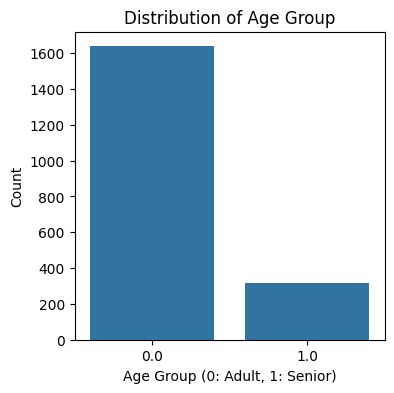

Best Parameters from GridSearch: {'model__C': 10, 'model__penalty': 'l2'}
Best Cross-Validation F1 Score: 0.11713238982646887

=== Validation Classification Report ===
              precision    recall  f1-score   support

         0.0       0.84      0.98      0.91       328
         1.0       0.33      0.06      0.11        63

    accuracy                           0.83       391
   macro avg       0.59      0.52      0.51       391
weighted avg       0.76      0.83      0.78       391

Validation F1 Score: 0.10666666666666667


TypeError: only length-1 arrays can be converted to Python scalars

In [ ]:
# Step 0: Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules for modeling
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

# Step 1: Load the Data
train = pd.read_csv('Train_Data.csv')
test = pd.read_csv('Test_Data.csv')

# Step 2: Preliminary Check for Missing Values in the Target
# Before mapping, check how many missing values the target column has
print("Missing target values BEFORE mapping:", train['age_group'].isnull().sum())

# Step 3: Map the Target Variable
# Map 'Adult' to 0 and 'Senior' to 1 (rows with other values will become NaN)
train['age_group'] = train['age_group'].map({'Adult': 0, 'Senior': 1})
print("Missing target values AFTER mapping:", train['age_group'].isnull().sum())

# Step 4: Drop Rows with Missing Target Values
# Rows with NaN in the target variable cannot be used for training
train = train.dropna(subset=['age_group'])
print("Shape after dropping missing targets:", train.shape)

# Step 5: Data Preprocessing
# Remove the identifier column 'SEQN'
X = train.drop(columns=['age_group', 'SEQN'])
y = train['age_group']

# For test data, remove the identifier column as well
X_test = test.drop(columns=['SEQN'])

# Optional: Visualize the target distribution
plt.figure(figsize=(4, 4))
sns.countplot(x=y)
plt.title("Distribution of Age Group")
plt.xlabel("Age Group (0: Adult, 1: Senior)")
plt.ylabel("Count")
plt.show()

# Step 6: Build a Pipeline for Preprocessing and Modeling
# The pipeline includes:
#   - SimpleImputer (median strategy) to handle missing values in features
#   - StandardScaler to standardize features
#   - Logistic Regression as the baseline model
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

# Step 7: Cross-Validation and Hyperparameter Tuning
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2']  # Note: 'l1' requires a different solver like 'liblinear'
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipeline, param_grid, cv=skf, scoring='f1', n_jobs=-1)
grid_search.fit(X, y)

# Print best parameters and cross-validation F1 score
print("Best Parameters from GridSearch:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", grid_search.best_score_)

# Step 8: Additional Evaluation on a Validation Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# Train best model on training split
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
# Predict on validation set
y_val_pred = best_model.predict(X_val)

print("\n=== Validation Classification Report ===")
print(classification_report(y_val, y_val_pred))
val_f1 = f1_score(y_val, y_val_pred)
print("Validation F1 Score:", val_f1)

# Step 9: Final Training and Prediction on Test Data
best_model.fit(X, y)
test_predictions = (best_model.predict(X_test))

# Step 10: Create and Save the Submission File
submission = pd.DataFrame({'age_group': test_predictions})
submission.to_csv('submission.csv', index=False)
print("\nSubmission file 'submission.csv' created successfully!")